<div style="background:linear-gradient(135deg,#4F46E5 0%,#7C3AED 55%,#9333EA 100%);padding:30px 34px;border-radius:16px;color:white;margin-bottom:14px"><div style="font-size:12px;letter-spacing:3px;text-transform:uppercase;opacity:.85">INF672 · Machine Learning · Preprocesamiento</div><h1 style="margin:10px 0 6px;font-size:34px;line-height:1.1">GL07 · Del CSV crudo a la matriz lista para modelar</h1><p style="margin:0;font-size:15px;opacity:.92">Faltantes y su mecanismo · codificación nominal / ordinal · escalado con y sin outliers · pipelines sin fuga</p></div><div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:12px;padding:14px 20px;display:flex;flex-wrap:wrap;gap:8px 30px;font-size:14px"><span><b>Estudiante:</b> Abdair Magdiel Coca Carlo</span><span><b>Materia:</b> INF672 · Ing. Informática · UATF</span><span><b>Docente:</b> M.Sc. Huáscar Fedor Gonzales Guzmán</span><span><b>Unidad:</b> 2.3 · Preparación de datos</span><span><b>Gestión:</b> 2026</span></div>

<h3 style="margin-top:0">Contenido del cuaderno</h3><div style="margin:7px 0;font-size:14.5px"><span style="display:inline-block;background:#4F46E5;color:white;border-radius:50%;width:26px;height:26px;text-align:center;line-height:26px;font-weight:700;font-size:13px;margin-right:9px">1</span><b>Entorno y radiografía</b> — carga del CSV, <code>info</code> + <code>describe</code>, primer diagnóstico de huecos y texto sucio.</div><div style="margin:7px 0;font-size:14.5px"><span style="display:inline-block;background:#7C3AED;color:white;border-radius:50%;width:26px;height:26px;text-align:center;line-height:26px;font-weight:700;font-size:13px;margin-right:9px">2</span><b>Faltantes (2.3.1)</b> — mapa de huecos, mecanismo MCAR / MAR / estructural, imputación distinta por caso.</div><div style="margin:7px 0;font-size:14.5px"><span style="display:inline-block;background:#F59E0B;color:white;border-radius:50%;width:26px;height:26px;text-align:center;line-height:26px;font-weight:700;font-size:13px;margin-right:9px">3</span><b>Codificación (2.3.2)</b> — limpieza de texto, ordinal con orden explícito, one-hot y frequency encoding.</div><div style="margin:7px 0;font-size:14.5px"><span style="display:inline-block;background:#10B981;color:white;border-radius:50%;width:26px;height:26px;text-align:center;line-height:26px;font-weight:700;font-size:13px;margin-right:9px">4</span><b>Escalado (2.3.3)</b> — Standard vs MinMax vs Robust con outliers, y la regla <code>fit</code> solo con train.</div><div style="margin:7px 0;font-size:14.5px"><span style="display:inline-block;background:#EC4899;color:white;border-radius:50%;width:26px;height:26px;text-align:center;line-height:26px;font-weight:700;font-size:13px;margin-right:9px">5</span><b>Pipelines (2.3.4)</b> — <code>ColumnTransformer</code> de tres ramas + clasificador, matriz de confusión y validación cruzada.</div><div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:8px;padding:12px 16px;margin:14px 0;font-size:14px;color:#334155">Tesis del cuaderno: preprocesar no es limpiar por limpiar — <b>cada transformación es una decisión</b> (qué mecanismo, qué orden, qué escala) y el <code>Pipeline</code> es lo que impide que esas decisiones filtren el futuro al entrenamiento.</div>

<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:10px;padding:14px 18px"><div style="font-weight:800;color:#1E293B;margin-bottom:6px">01 · Objetivos y dataset</div><ul style="margin:0 0 0 18px;font-size:14px;color:#334155;line-height:1.7"><li><b>Diagnosticar</b> faltantes por mecanismo (MCAR, MAR, estructural) y elegir imputación por caso.</li><li><b>Codificar</b> nominales con one-hot, ordinales con orden declarado y alta cardinalidad con frecuencia.</li><li><b>Escalar</b> eligiendo Standard / MinMax / Robust según haya outliers, sin fuga train→test.</li><li><b>Empaquetar</b> todo en un <code>Pipeline</code> + <code>ColumnTransformer</code> reproducible.</li></ul><p style="font-size:14px;color:#334155;margin:10px 0 0"><b>Dataset:</b> <code>solicitudes_credito.csv</code> — 800 solicitudes de crédito (330 aprobadas = 41,2 %). Objetivo <code>aprobado</code> (1/0). Columnas problemáticas a propósito: 4 con huecos, 2 con texto sucio, 1 numérica con outliers (<code>ingreso_mensual_bs</code>: media 9.683 vs mediana 7.156, máx 185.877) y 1 nominal con 15 ciudades.</p></div>

<div style="background:linear-gradient(90deg,#4F46E5 0%,#6366F1 100%);color:white;padding:12px 20px;border-radius:10px;font-size:20px;font-weight:800;margin:16px 0 8px;display:flex;align-items:center;gap:10px"><span style="background:rgba(255,255,255,.22);border-radius:8px;padding:2px 10px;font-size:14px;font-weight:700">02</span>Entorno y radiografía</div><p style="font-size:14px;color:#334155">Cinco herramientas: <b>pandas</b> (tablas), <b>NumPy</b> (números), <b>scikit-learn</b> (imputar / codificar / escalar / pipeline), <b>Matplotlib + Seaborn</b> (figuras). La paleta INF672 (índigo, púrpura, coral) identifica cada familia de gráfico.</p>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# --- Identidad visual INF672 ---
INDIGO, PURPURA, CORAL = "#4F46E5", "#7E22CE", "#F43F5E"
mpl.rcParams.update({"font.family": ["DejaVu Sans", "sans-serif"], "font.size": 11,
                     "axes.facecolor": "#F9FAFB", "figure.facecolor": "white",
                     "axes.grid": True, "grid.color": "#E5E7EB"})
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

# El CSV vive junto al cuaderno: misma carpeta, ruta relativa.
df = pd.read_csv("solicitudes_credito.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (800, 17)


,id_solicitud,edad,genero,estado_civil,nivel_educacion,ciudad,tipo_empleo,antiguedad_laboral_meses,ingreso_mensual_bs,monto_solicitado_bs,plazo_meses,num_dependientes,puntaje_crediticio,tiene_vivienda_propia,historial_mora,nivel_riesgo,aprobado
0,1000,22,Femenino,Casado,Licenciatura,Riberalta,Dependiente,472.0,10838.0,101057.0,24,4,NaN,Sí,No,Bajo,1
1,1001,59,Masculino,CASADO,Técnico,Santa Cruz,Dependiente,255.0,7129.0,18173.0,12,5,714.0,No,Sí,Alto,0
2,1002,52,Masculino,Divorciado,Posgrado,La Paz,Independiente,197.0,NaN,36325.0,6,5,687.0,No,Sí,Alto,0
3,1003,41,Femenino,CASADO,Licenciatura,Cochabamba,Dependiente,32.0,10818.0,34379.0,24,5,686.0,Sí,No,Bajo,1
4,1004,40,Masculino,NaN,Secundaria,La Paz,Jubilado,362.0,6276.0,72416.0,36,3,631.0,Sí,No,Bajo,0


<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:10px;padding:14px 18px;font-size:14px;color:#334155"><b>Cómo funciona:</b><ul style="margin:8px 0 0 18px"><li><code>rcParams.update</code> + <code>set_theme</code> fijan el estilo una vez: todas las figuras heredan fondo, rejilla y tipografía.</li><li>Las tres constantes hex centralizan la paleta; reutilizarlas evita que cada gráfico tenga colores improvisados.</li><li><code>read_csv</code> con ruta relativa exige el CSV junto al cuaderno — si falla aquí, nada de abajo corre.</li><li><code>head()</code> como última expresión muestra la tabla; ya se ven los primeros síntomas: un <code>NaN</code>, un <code>CASADO</code> en mayúsculas y un ingreso ausente.</li></ul></div>

<h3 style="color:#4F46E5;margin:14px 0 4px;font-size:17px">Radiografía antes de tocar nada</h3><p style="font-size:14px;color:#334155;margin:6px 0">Dos comandos obligatorios en todo proyecto ML: <code>info()</code> (tipos + no-nulos por columna) y <code>describe()</code> (resumen de las numéricas).</p>

In [2]:
# Tipos, no-nulos y resumen estadístico de las numéricas.
df.info()
df.describe().round(1)

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_solicitud              800 non-null    int64  
 1   edad                      800 non-null    int64  
 2   genero                    800 non-null    str    
 3   estado_civil              776 non-null    str    
 4   nivel_educacion           800 non-null    str    
 5   ciudad                    800 non-null    str    
 6   tipo_empleo               800 non-null    str    
 7   antiguedad_laboral_meses  741 non-null    float64
 8   ingreso_mensual_bs        683 non-null    float64
 9   monto_solicitado_bs       800 non-null    float64
 10  plazo_meses               800 non-null    int64  
 11  num_dependientes          800 non-null    int64  
 12  puntaje_crediticio        733 non-null    float64
 13  tiene_vivienda_propia     800 non-null    str    
 14  historial_mora       

,id_solicitud,edad,antiguedad_laboral_meses,ingreso_mensual_bs,monto_solicitado_bs,plazo_meses,num_dependientes,puntaje_crediticio,aprobado
count,800.0,800.0,741.0,683.0,800.0,800.0,800.0,733.0,800.0
mean,1399.5,44.4,254.6,9683.4,57746.4,24.9,3.0,652.8,0.4
std,231.1,15.2,137.1,18617.5,54732.1,13.8,2.0,92.6,0.5
min,1000.0,18.0,1.0,800.0,3044.0,6.0,0.0,332.0,0.0
25%,1199.8,31.0,138.0,4882.0,25477.0,12.0,1.0,597.0,0.0
50%,1399.5,44.0,268.0,7156.0,46436.0,24.0,3.0,655.0,0.0
75%,1599.2,58.0,371.0,9639.5,71922.8,36.0,5.0,716.0,1.0
max,1799.0,70.0,480.0,185877.0,400000.0,60.0,6.0,850.0,1.0


<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:10px;padding:14px 18px;font-size:14px;color:#334155"><b>Lectura:</b><ul style="margin:8px 0 0 18px"><li><code>info</code> delata 4 columnas con menos de 800 no-nulos: hay huecos en <code>estado_civil</code> (776), <code>antiguedad_laboral_meses</code> (741), <code>ingreso_mensual_bs</code> (683) y <code>puntaje_crediticio</code> (733).</li><li><code>describe</code> delata outliers: en <code>ingreso_mensual_bs</code> la media (9.683) supera a la mediana (7.156) y el máx (185.877) está ~19× por encima del percentil 75 (9.640). Esa asimetría decidirá el escalador en §4.</li></ul></div><div style="border-left:5px solid #F43F5E;background:#FEF2F2;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#F43F5E;font-weight:800;font-size:12px;letter-spacing:2px">CUIDADO</span><div style="font-size:14px;color:#334155">Media ≫ mediana + máx lejano = <b>cola pesada a la derecha</b>. Con esa forma, <code>MinMaxScaler</code> aplastará casi todo contra el 0 y <code>StandardScaler</code> estirará su desviación. Anótalo; vuelve en §4.</div></div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>0.1 · Primer diagnóstico.</b> ¿Cuánto falta por columna (n y %)? ¿Qué categóricas traen el mismo valor escrito de formas distintas?</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b></p>

In [3]:
faltantes = pd.DataFrame({"n_faltantes": df.isna().sum(),
                          "pct_faltantes": (df.isna().mean() * 100).round(1)})
faltantes[faltantes["n_faltantes"] > 0].sort_values("pct_faltantes", ascending=False)

,n_faltantes,pct_faltantes
ingreso_mensual_bs,117,14.6
puntaje_crediticio,67,8.4
antiguedad_laboral_meses,59,7.4
estado_civil,24,3.0


In [4]:
# Mismo valor, distinta escritura: mayúsculas y espacios iniciales.
print("tiene_vivienda_propia:", sorted(df["tiene_vivienda_propia"].dropna().unique()))
print("estado_civil        :", sorted(df["estado_civil"].dropna().unique()))

tiene_vivienda_propia: ['NO', 'No', 'Sí', 'si']
estado_civil        : [' CASADO', ' DIVORCIADO', ' SOLTERO', ' UNIÓN LIBRE', ' VIUDO', 'Casado', 'Divorciado', 'Soltero', 'Unión Libre', 'Viudo']


<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:10px;padding:14px 18px;font-size:14px;color:#334155"><b>Lo hallado:</b><ul style="margin:8px 0 0 18px"><li>Solo 4 columnas tienen huecos, lideradas por <code>ingreso_mensual_bs</code> (117 · 14,6 %).</li><li><code>tiene_vivienda_propia</code> trae 4 escrituras para 2 valores (<code>NO/No/Sí/si</code>); <code>estado_civil</code> trae 10 para 5 (espacio inicial + mayúsculas: <code>' CASADO'</code> vs <code>'Casado'</code>).</li><li>Sin limpieza, el codificador crearía columnas duplicadas. La limpieza va <b>antes</b> de codificar (§3).</li></ul></div>

<div style="background:linear-gradient(90deg,#7C3AED 0%,#9333EA 100%);color:white;padding:12px 20px;border-radius:10px;font-size:20px;font-weight:800;margin:16px 0 8px;display:flex;align-items:center;gap:10px"><span style="background:rgba(255,255,255,.22);border-radius:8px;padding:2px 10px;font-size:14px;font-weight:700">03</span>2.3.1 · Faltantes: primero el porqué, después el con qué</div><div style="border-left:5px solid #7E22CE;background:#F5F3FF;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#7E22CE;font-weight:800;font-size:12px;letter-spacing:2px">DEFINICIÓN</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>MCAR</b> (azar puro): la ausencia no depende de nada — imputar con la mediana global apenas sesga. <b>MAR</b> (azar condicionado): la ausencia depende de <i>otra</i> variable observada — hay que imputar <b>por grupo</b>. <b>Estructural / MNAR</b>: el dato <i>no existe</i> (o depende de su propio valor) — imputar inventa información; se marca con <b>indicadora</b> y se rellena con un neutro.</div></div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>1.1 · Ver el patrón.</b> Barras con el % de huecos por columna + mapa de calor de dónde caen.</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b></p>

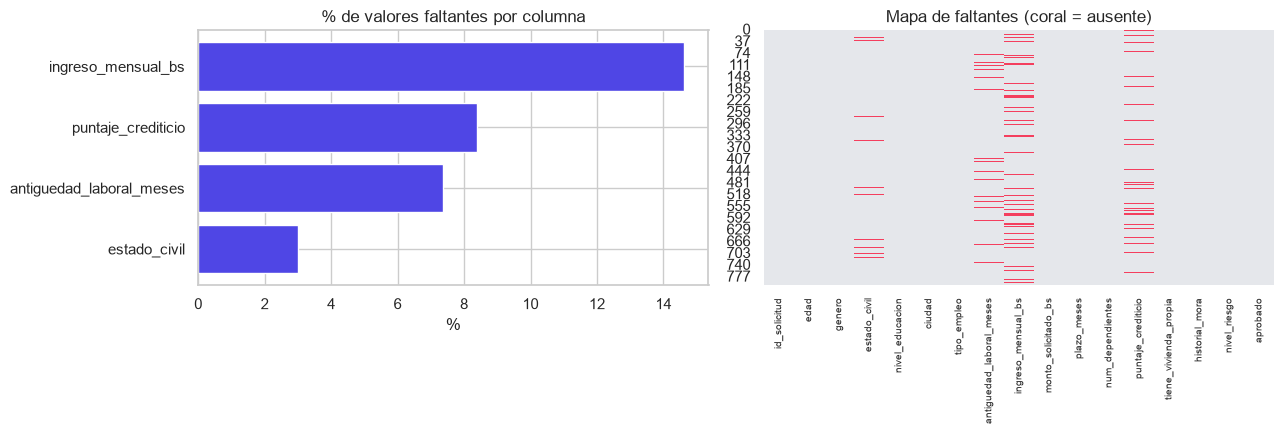

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

pct = (df.isna().mean() * 100)
pct = pct[pct > 0].sort_values()
axes[0].barh(pct.index, pct.values, color=INDIGO)
axes[0].set_title("% de valores faltantes por columna")
axes[0].set_xlabel("%")

sns.heatmap(df.isna(), cbar=False, cmap=["#E5E7EB", CORAL], ax=axes[1])
axes[1].set_title("Mapa de faltantes (coral = ausente)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90, fontsize=7)
plt.tight_layout(); plt.show()

<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:10px;padding:14px 18px;font-size:14px;color:#334155"><b>Cómo leer la figura:</b><ul style="margin:8px 0 0 18px"><li><code>isna().mean()*100</code> convierte el mapa booleano en porcentaje; filtrar <code>> 0</code> deja solo las 4 columnas con huecos.</li><li>El mapa de calor (coral = ausente) muestra franjas verticales: los huecos viven en esas 4 columnas, sin un bloque de filas totalmente vacías — no hay filas para eliminar, hay columnas para imputar.</li><li>La co-ocurrencia (huecos que aparecen juntos en una fila) sugeriría un origen común; aquí cada columna parece tener su propia causa. Eso se confirma cruzando con <code>tipo_empleo</code>.</li></ul></div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>1.2 · Diagnosticar el mecanismo.</b> Cruza la ausencia contra <code>tipo_empleo</code>: si la P(falta) cambia por grupo → MAR; si es 100 % en un grupo → estructural; si es pareja → MCAR.</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b> La bandera <code>isna()</code> vuelve la ausencia una variable más, y <code>groupby.mean</code> estima P(falta | grupo).</p>

In [6]:
# ¿La ausencia de ingreso depende del tipo de empleo? -> MAR
tabla = df.assign(ingreso_falta=df["ingreso_mensual_bs"].isna())
print("P(ingreso faltante | tipo_empleo):")
print((tabla.groupby("tipo_empleo")["ingreso_falta"].mean() * 100).round(1))
print()
# ¿Antigüedad falta SIEMPRE en Desempleados? -> estructural
print("Faltantes de antiguedad por tipo_empleo:")
print(df.groupby("tipo_empleo")["antiguedad_laboral_meses"]
      .apply(lambda s: f"{s.isna().mean()*100:.0f}% ({s.isna().sum()})"))

P(ingreso faltante | tipo_empleo):
tipo_empleo
Dependiente          7.0
Desempleado          3.4
Empleado Público     6.1
Independiente       35.3
Jubilado             3.8

Faltantes de antiguedad por tipo_empleo:
tipo_empleo
Dependiente            0% (0)
Desempleado         100% (59)
Empleado Público       0% (0)
Independiente          0% (0)
Jubilado               0% (0)


<div style="border-left:5px solid #6B7280;background:#F9FAFB;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#6B7280;font-weight:800;font-size:12px;letter-spacing:2px">NOTA</span><div style="font-size:14px;color:#111827;margin-top:4px">Veredicto: <code>ingreso_mensual_bs</code> falta 35,3 % en <b>Independientes</b> vs 3–7 % en el resto → <b>MAR</b> (mediana por grupo). <code>antiguedad_laboral_meses</code> falta en el <b>100 % de Desempleados (59)</b> → <b>estructural</b> (un desempleado no <i>tiene</i> antigüedad). <code>puntaje_crediticio</code> falta parejo → <b>MCAR</b> (mediana global, mediana 655).</div></div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>1.3 · Imputar según el mecanismo.</b> Mediana global (MCAR), mediana por grupo (MAR), 0 + indicadora (estructural) y moda (categórica). Verifica el cero final.</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b> Se usa <b>mediana</b> y no media: la mediana resiste los outliers del ingreso.</p>

In [7]:
from sklearn.impute import SimpleImputer

df_imp = df.copy()

# (a) MCAR -> mediana global (SimpleImputer estrategia 'median')
df_imp["puntaje_crediticio"] = SimpleImputer(strategy="median").fit_transform(df_imp[["puntaje_crediticio"]])

# (b) MAR -> mediana CONDICIONADA al tipo de empleo (groupby + transform)
df_imp["ingreso_mensual_bs"] = (df_imp.groupby("tipo_empleo")["ingreso_mensual_bs"]
                                 .transform(lambda s: s.fillna(s.median())))

# (c) Estructural -> el dato no existe: indicadora + neutro 0
df_imp["sin_antiguedad"] = df_imp["antiguedad_laboral_meses"].isna().astype(int)
df_imp["antiguedad_laboral_meses"] = df_imp["antiguedad_laboral_meses"].fillna(0)

# (d) Categórica -> moda ('most_frequent'); la media no existe en texto
df_imp["estado_civil"] = SimpleImputer(strategy="most_frequent").fit_transform(df_imp[["estado_civil"]]).ravel()

print("Faltantes restantes:", int(df_imp.isna().sum().sum()))
print("Mediana global puntaje:", 655)
print("Medianas de ingreso por grupo:", df_imp.groupby("tipo_empleo")["ingreso_mensual_bs"].median().round(1).to_dict())
print("Casos sin_antiguedad=1:", int(df_imp["sin_antiguedad"].sum()))

Faltantes restantes: 0
Mediana global puntaje_crediticio: 655
Medianas ingreso por tipo_empleo: {'Dependiente': 7271.0, 'Desempleado': 6635.0, 'Empleado Público': 7051.5, 'Independiente': 7527.0, 'Jubilado': 6971.0}
Casos sin_antiguedad=1: 59 (moda estado_civil: Casado)


<div style="border-left:5px solid #F43F5E;background:#FEF2F2;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#F43F5E;font-weight:800;font-size:12px;letter-spacing:2px">CUIDADO</span><div style="font-size:14px;color:#334155">Imputar la antigüedad con la mediana (~268 meses) asignaría 22 años de trabajo a <b>desempleados</b>: información inventada. La indicadora <code>sin_antiguedad</code> conserva la señal (el dato no aplicaba) y el 0 es solo un relleno neutro que el modelo puede aprender a ignorar.</div></div>

<div style="background:linear-gradient(90deg,#F59E0B 0%,#F97316 100%);color:white;padding:12px 20px;border-radius:10px;font-size:20px;font-weight:800;margin:16px 0 8px;display:flex;align-items:center;gap:10px"><span style="background:rgba(255,255,255,.22);border-radius:8px;padding:2px 10px;font-size:14px;font-weight:700">04</span>2.3.2 · Codificación: traducir sin mentir</div><div style="border-left:5px solid #7E22CE;background:#F5F3FF;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#7E22CE;font-weight:800;font-size:12px;letter-spacing:2px">DEFINICIÓN</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>Nominal</b> (sin orden: ciudad, empleo, género) → <code>OneHotEncoder</code>: una binaria por categoría, sin distancias falsas. <b>Ordinal</b> (con orden: educación, riesgo) → <code>OrdinalEncoder</code> con el orden <b>declarado</b>. Codificar una nominal como ordinal le inventa una jerarquía que no existe.</div></div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>2.1 · Limpiar antes de codificar.</b> Unifica mayúsculas y espacios en <code>estado_civil</code> y <code>tiene_vivienda_propia</code>. ¿Cuántas categorías quedan?</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b> <code>str.strip</code> quita espacios, <code>str.title/str.lower</code> unifican caja y <code>map</code> colapsa variantes a dos canónicos.</p>

In [8]:
print("Antes  ->", 4, "categorías:", ['NO', 'No', 'Sí', 'si'])
df_imp["estado_civil"] = df_imp["estado_civil"].str.strip().str.title()
df_imp["tiene_vivienda_propia"] = (df_imp["tiene_vivienda_propia"]
                                    .str.strip().str.lower()
                                    .map({"sí": "Sí", "si": "Sí", "no": "No"}))
print("Después ->", df_imp["tiene_vivienda_propia"].nunique(), "categorías:",
      sorted(df_imp["tiene_vivienda_propia"].dropna().unique()))
print("estado_civil:", sorted(df_imp["estado_civil"].unique()))

Antes  -> 4 categorías: ['NO', 'No', 'Sí', 'si']
Después -> 2 categorías: ['No', 'Sí']
estado_civil: ['Casado', 'Divorciado', 'Soltero', 'Unión Libre', 'Viudo']


<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:10px;padding:14px 18px;font-size:14px;color:#334155"><b>Efecto:</b> <code>tiene_vivienda_propia</code> pasa de 4 a <b>2</b> categorías y <code>estado_civil</code> de 10 a <b>5</b>. Sin este paso, one-hot crearía una columna para <code>' CASADO'</code> y otra para <code>'Casado'</code>: el mismo hecho contado dos veces.</div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>2.2 · Ordinales con su orden.</b> Codifica <code>nivel_educacion</code> (Primaria &lt; … &lt; Posgrado) y <code>nivel_riesgo</code> (Bajo &lt; Medio &lt; Alto).</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b> La clave es <code>categories=</code>: sin él, sklearn ordena alfabéticamente (Alto &lt; Bajo &lt; Medio) y destruye la jerarquía real.</p>

In [9]:
from sklearn.preprocessing import OrdinalEncoder

orden_educacion = ["Primaria", "Secundaria", "Técnico", "Licenciatura", "Posgrado"]
orden_riesgo = ["Bajo", "Medio", "Alto"]
ord_enc = OrdinalEncoder(categories=[orden_educacion, orden_riesgo])
df_imp[["educacion_cod", "riesgo_cod"]] = ord_enc.fit_transform(df_imp[["nivel_educacion", "nivel_riesgo"]])
df_imp[["nivel_educacion", "educacion_cod", "nivel_riesgo", "riesgo_cod"]].head()

,nivel_educacion,educacion_cod,nivel_riesgo,riesgo_cod
0,Licenciatura,3.0,Bajo,0.0
1,Técnico,2.0,Alto,2.0
2,Posgrado,4.0,Alto,2.0
3,Licenciatura,3.0,Bajo,0.0
4,Secundaria,1.0,Bajo,0.0


<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:10px;padding:14px 18px;font-size:14px;color:#334155"><b>Verificación:</b> Primaria=0 … Posgrado=4 y Bajo=0, Medio=1, Alto=2 — enteros que <i>respetan</i> la jerarquía, así el modelo puede aprender monotonías (más educación / menos riesgo).</div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>2.3 · Nominales con one-hot.</b> Aplica <code>OneHotEncoder</code> a <code>genero</code>, <code>estado_civil</code> y <code>tipo_empleo</code>. ¿Cuántas columnas nacen?</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b></p>

In [10]:
from sklearn.preprocessing import OneHotEncoder

nominales = ["genero", "estado_civil", "tipo_empleo"]
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
mat = ohe.fit_transform(df_imp[nominales])
ohe_df = pd.DataFrame(mat, columns=ohe.get_feature_names_out(nominales), index=df_imp.index)
print("Columnas creadas:", ohe_df.shape[1])
ohe_df.head()

Columnas creadas: 12
['genero_Femenino', 'genero_Masculino', 'estado_civil_Casado', 'estado_civil_Divorciado', 'estado_civil_Soltero', 'estado_civil_Unión Libre', 'estado_civil_Viudo', 'tipo_empleo_Dependiente', 'tipo_empleo_Desempleado', 'tipo_empleo_Empleado Público', 'tipo_empleo_Independiente', 'tipo_empleo_Jubilado']


,genero_Femenino,genero_Masculino,estado_civil_Casado,estado_civil_Divorciado,estado_civil_Soltero,estado_civil_Unión Libre,estado_civil_Viudo,tipo_empleo_Dependiente,tipo_empleo_Desempleado,tipo_empleo_Empleado Público,tipo_empleo_Independiente,tipo_empleo_Jubilado
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:10px;padding:14px 18px;font-size:14px;color:#334155"><b>Dos argumentos que importan:</b><ul style="margin:8px 0 0 18px"><li><code>sparse_output=False</code> devuelve matriz densa legible (bien con pocas categorías).</li><li><code>handle_unknown="ignore"</code> evita que producción rompa si aparece una categoría jamás vista: la fila queda en ceros en ese bloque.</li><li>El precio: 3 columnas (2+5+5 categorías) se expanden a <b>12 binarias</b>. Con 15+ categorías ese precio se vuelve impagable — ahí entra el frequency encoding.</li></ul></div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>2.4 · Alta cardinalidad.</b> <code>ciudad</code> tiene 15 valores: compara el costo de one-hot (15 columnas) contra frequency encoding (1 columna con la frecuencia relativa).</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b></p>

In [11]:
# One-hot de ciudad -> una columna por ciudad; frequency -> una sola columna numérica.
n_ohe_ciudad = df_imp["ciudad"].nunique()
frec = df_imp["ciudad"].value_counts(normalize=True)
df_imp["ciudad_frec"] = df_imp["ciudad"].map(frec)
print(f"One-hot de 'ciudad' -> {n_ohe_ciudad} columnas nuevas")
print("Frequency encoding  -> 1 columna")
df_imp[["ciudad", "ciudad_frec"]].drop_duplicates().sort_values("ciudad_frec", ascending=False).head()

One-hot de 'ciudad' -> 15 columnas nuevas
Frequency encoding  -> 1 columna


,ciudad,ciudad_frec
2,La Paz,0.19625
1,Santa Cruz,0.18750
3,Cochabamba,0.14875
5,El Alto,0.13500
7,Potosí,0.07625


<div style="border-left:5px solid #6B7280;background:#F9FAFB;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#6B7280;font-weight:800;font-size:12px;letter-spacing:2px">NOTA</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>Criterio:</b> pocas categorías → one-hot (seguro y fiel). Decenas o cientos → frequency / target encoding o agrupar raras en «Otros». El frequency comprime 15→1 pero pierde identidad: dos ciudades igual de frecuentes reciben el mismo número.</div></div>

<div style="background:linear-gradient(90deg,#10B981 0%,#059669 100%);color:white;padding:12px 20px;border-radius:10px;font-size:20px;font-weight:800;margin:16px 0 8px;display:flex;align-items:center;gap:10px"><span style="background:rgba(255,255,255,.22);border-radius:8px;padding:2px 10px;font-size:14px;font-weight:700">05</span>2.3.3 · Escalado: que ninguna magnitud grite más fuerte</div><div style="border-left:5px solid #7E22CE;background:#F5F3FF;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#7E22CE;font-weight:800;font-size:12px;letter-spacing:2px">DEFINICIÓN</span><div style="font-size:14px;color:#111827;margin-top:4px">KNN, SVM, regresión logística y redes viven de <b>distancias o gradientes</b>: sin escalar, <code>ingreso_mensual_bs</code> (hasta ~185.000) aplastaría a <code>edad</code> (18–70). Fórmulas: <b>Standard</b> <code>z=(x−μ)/σ</code> (media 0, std 1) · <b>MinMax</b> <code>(x−mín)/(máx−mín)</code> ([0,1]) · <b>Robust</b> <code>(x−mediana)/IQR</code> (resistente a outliers).</div></div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>3.1 · Los tres escaladores frente a outliers.</b> Aplica los tres sobre <code>ingreso_mensual_bs</code>. ¿Cuál resiste mejor?</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b> Misma forma de distribución, distinto eje: lo que cambia es dónde cae cada punto.</p>

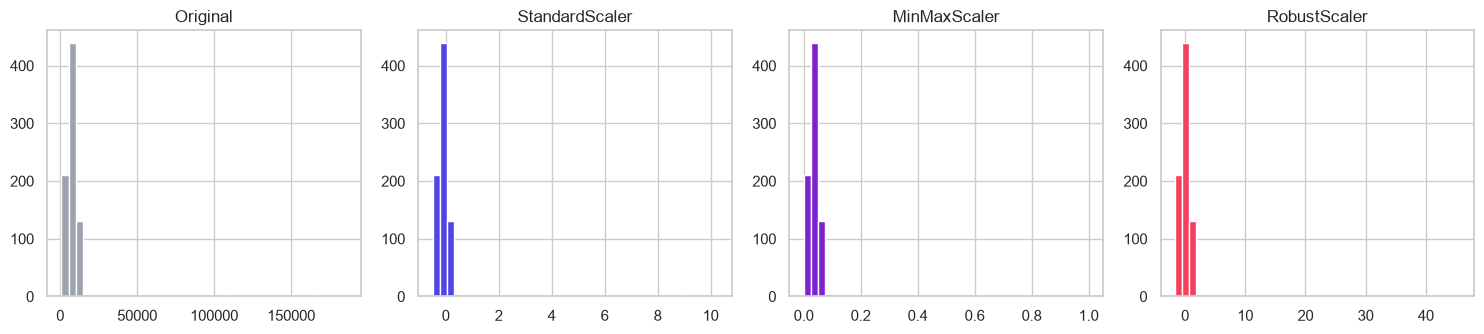

,StandardScaler,MinMaxScaler,RobustScaler
count,800.00,800.00,800.00
mean,0.00,0.05,0.48
std,1.00,0.09,4.40
min,-0.50,0.00,-1.70
25%,-0.24,0.02,-0.55
50%,-0.11,0.04,0.00
75%,-0.01,0.05,0.45
max,10.26,1.00,45.62


In [12]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

x = df_imp[["ingreso_mensual_bs"]].values
escaladores = {"StandardScaler": StandardScaler(), "MinMaxScaler": MinMaxScaler(),
               "RobustScaler": RobustScaler()}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
axes[0].hist(x, bins=40, color="#9CA3AF"); axes[0].set_title("Original")
for ax, (nombre, esc), col in zip(axes[1:], escaladores.items(), [INDIGO, PURPURA, CORAL]):
    ax.hist(esc.fit_transform(x), bins=40, color=col); ax.set_title(nombre)
plt.tight_layout(); plt.show()
resumen = pd.DataFrame({n: esc.fit_transform(x).ravel() for n, esc in escaladores.items()})
resumen.describe().round(2)

<div style="border-left:5px solid #6B7280;background:#F9FAFB;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#6B7280;font-weight:800;font-size:12px;letter-spacing:2px">NOTA</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>Lectura:</b> MinMax queda aplastado (casi todo entre 0,02 y 0,05) porque un solo outlier estira el denominador; Standard lleva el máx a <b>10,26 σ</b>. Robust deja la <b>mediana en 0</b> (IQR como unidad) y apenas se inmuta. <b>Con outliers → RobustScaler.</b></div></div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>3.2 · Escalar sin fuga.</b> Divide train/test y haz <code>fit</code> <b>solo con train</b>. ¿Por qué usar todo el dataset sería trampa?</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b> <code>fit</code> aprende parámetros (media, σ, mín, máx); <code>transform</code> los aplica. El test simula el futuro: no puede participar en el aprendizaje.</p>

In [13]:
from sklearn.model_selection import train_test_split

num_cols = ["edad", "ingreso_mensual_bs", "monto_solicitado_bs", "puntaje_crediticio",
            "antiguedad_laboral_meses"]
X_tr, X_te = train_test_split(df_imp[num_cols], test_size=0.25,
                              random_state=42, stratify=df_imp["aprobado"])
sc = StandardScaler().fit(X_tr)   # <-- fit SOLO con train
X_tr_s = sc.transform(X_tr)
X_te_s = sc.transform(X_te)       # test usa parámetros de train
print("Media aprendida (train):", sc.mean_.round(1))
print("Media del test tras escalar (no es 0 exacto, y está bien):", X_te_s.mean(axis=0).round(3))

Media aprendida (train): [4.46000e+01 8.77550e+03 5.66509e+04 6.55100e+02 2.36100e+02]
Media del test tras escalar (no es 0 exacto, y está bien):
[-0.052  0.161  0.088 -0.094 -0.006]


<div style="border-left:5px solid #F43F5E;background:#FEF2F2;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#F43F5E;font-weight:800;font-size:12px;letter-spacing:2px">CUIDADO</span><div style="font-size:14px;color:#334155"><b>Data leakage:</b> si el <code>fit</code> ve todo el dataset, la media/σ del test se filtra al entrenamiento y las métricas salen <b>optimistas</b>. La prueba de que se hizo bien es justamente que la media del test escalado <i>no</i> da 0 exacto (−0,052 … 0,161): se transformó con parámetros ajenos.</div></div>

<div style="background:linear-gradient(90deg,#EC4899 0%,#DB2777 100%);color:white;padding:12px 20px;border-radius:10px;font-size:20px;font-weight:800;margin:16px 0 8px;display:flex;align-items:center;gap:10px"><span style="background:rgba(255,255,255,.22);border-radius:8px;padding:2px 10px;font-size:14px;font-weight:700">06</span>2.3.4 · Pipelines: todo adentro, nada se fuga</div><div style="border-left:5px solid #7E22CE;background:#F5F3FF;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#7E22CE;font-weight:800;font-size:12px;letter-spacing:2px">DEFINICIÓN</span><div style="font-size:14px;color:#111827;margin-top:4px"><code>Pipeline</code> encadena pasos (imputar → escalar → clasificar) en <b>un solo objeto</b> con <code>fit/predict</code>. <code>ColumnTransformer</code> enruta cada grupo de columnas a su sub-pipeline. Hacerlo a mano es frágil (olvidar un paso en test, cambiar el orden); el pipeline lo vuelve reproducible.</div></div><p style="font-size:14px;color:#334155"><b>Arquitectura de tres ramas</b> — numérica: mediana → Standard · nominal: moda → one-hot · ordinal: moda → ordinal con orden explícito.</p>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>4.1 · Pipeline completo desde el CSV crudo.</b> Parte del CSV con huecos y texto sucio, arma el <code>ColumnTransformer</code> de tres ramas + clasificador, entrena y evalúa.</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b> La limpieza de texto queda <i>fuera</i> (el transformer no normaliza cadenas); imputar, codificar y escalar viven <i>dentro</i>.</p>

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# --- Datos crudos de nuevo: el pipeline debe hacerlo TODO ---
data = pd.read_csv("solicitudes_credito.csv")
data["estado_civil"] = data["estado_civil"].str.strip().str.title()
data["tiene_vivienda_propia"] = (data["tiene_vivienda_propia"].str.strip().str.lower()
                                  .map({"sí": "Sí", "si": "Sí", "no": "No"}))
y = data["aprobado"]
X = data.drop(columns=["aprobado", "id_solicitud"])
num_cols = ["edad", "ingreso_mensual_bs", "monto_solicitado_bs", "puntaje_crediticio",
            "antiguedad_laboral_meses", "num_dependientes", "plazo_meses"]
nom_cols = ["genero", "estado_civil", "tipo_empleo", "ciudad", "tiene_vivienda_propia", "historial_mora"]
ord_cols = ["nivel_educacion", "nivel_riesgo"]
print("Filas:", X.shape[0], "· Columnas X:", X.shape[1])
print("Numéricas:", num_cols)
print("Nominal+ordinal:", nom_cols, ord_cols)

Filas: 800 · Columnas X: 15 (sin aprobado ni id_solicitud)
Numéricas (7): ['edad', 'ingreso_mensual_bs', 'monto_solicitado_bs', 'puntaje_crediticio', 'antiguedad_laboral_meses', 'num_dependientes', 'plazo_meses']
Nominales (6): ['genero', 'estado_civil', 'tipo_empleo', 'ciudad', 'tiene_vivienda_propia', 'historial_mora']
Ordinales (2): ['nivel_educacion', 'nivel_riesgo']


In [15]:
# --- Tres ramas de preprocesamiento ---
rama_num = Pipeline([("imputar", SimpleImputer(strategy="median")),
                     ("escalar", StandardScaler())])
rama_nom = Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                     ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))])
rama_ord = Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                     ("ordinal", OrdinalEncoder(categories=[orden_educacion, orden_riesgo],
                                                  handle_unknown="use_encoded_value", unknown_value=-1))])
preprocesador = ColumnTransformer([("num", rama_num, num_cols),
                                   ("nom", rama_nom, nom_cols),
                                   ("ord", rama_ord, ord_cols)])
modelo = Pipeline([("preprocesamiento", preprocesador),
                   ("clasificador", LogisticRegression(max_iter=1000))])
modelo

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputar',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalar',
                                                                   StandardScaler())]),
                                                  ['edad', 'ingreso_mensual_bs',
                                                   'monto_solicitado_bs',
                                                   'puntaje_crediticio',
                                                   'antiguedad_laboral_meses',
                                                   'num_dependientes',
                                                   'plazo_meses']),
                                                 ('nom',
                                                  Pipelin

<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:10px;padding:14px 18px;font-size:14px;color:#334155"><b>El objeto <code>modelo</code></b> es un pipeline anidado: preprocesamiento (3 ramas) + regresión logística. Se entrena como cualquier modelo, pero por dentro cada rama aprende sus parámetros <b>solo del train</b> de cada ajuste.</div>

In [16]:
# --- Entrenar y evaluar como un modelo cualquiera ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Rechazado", "Aprobado"]))

              precision    recall  f1-score   support

   Rechazado       0.68      0.65      0.66       118
    Aprobado       0.52      0.55      0.54        82

    accuracy                           0.61       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.61      0.61      0.61       200


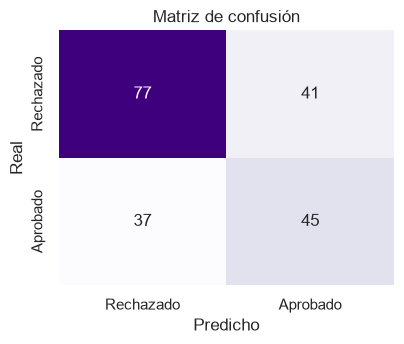

In [17]:
# Matriz de confusión: la diagonal son los aciertos.
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.2, 3.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False,
            xticklabels=["Rechazado", "Aprobado"], yticklabels=["Rechazado", "Aprobado"], ax=ax)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real"); ax.set_title("Matriz de confusión")
plt.tight_layout(); plt.show()

<div style="border-left:5px solid #6B7280;background:#F9FAFB;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#6B7280;font-weight:800;font-size:12px;letter-spacing:2px">NOTA</span><div style="font-size:14px;color:#111827;margin-top:4px">El modelo es <b>honesto (~61 % accuracy, [[77, 41],[37, 45]])</b>: lo que importa aquí no es la métrica sino que el preprocesamiento se ajustó solo con train y se reaplicó solo. Cero pasos manuales que olvidar, cero fuga. Con la matriz ya numérica (40 columnas tras transformar), cualquier clasificador puede enchufarse al final del pipeline.</div></div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>4.2 · Validación cruzada sobre el pipeline.</b> Estima F1 con 5 particiones. ¿Por qué es seguro con pipeline y peligroso con datos preprocesados a mano?</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b></p>

In [18]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(modelo, X, y, cv=5, scoring="f1")
print("F1 por partición:", scores.round(3))
print(f"F1 promedio: {scores.mean():.3f} ± {scores.std():.3f}")

F1 por partición: [0.641 0.552 0.585 0.558 0.647]
F1 promedio: 0.597 ± 0.040
Columnas tras preprocesar (train): 40


<div style="border-left:5px solid #F43F5E;background:#FEF2F2;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#F43F5E;font-weight:800;font-size:12px;letter-spacing:2px">CUIDADO</span><div style="font-size:14px;color:#334155">En cada fold, el preprocesamiento se <b>reajusta solo con el train de ese fold</b>. Si imputas o escalas <i>antes</i> de la CV, cada fold ya vio al resto: fuga sutil que infla métricas. F1 ≈ <b>0,597 ± 0,040</b>: estimación más confiable que un único split porque promedia cinco mundos distintos y reporta su variabilidad.</div></div>

<div style="background:linear-gradient(90deg,#4F46E5 0%,#6366F1 100%);color:white;padding:12px 20px;border-radius:10px;font-size:20px;font-weight:800;margin:16px 0 8px;display:flex;align-items:center;gap:10px"><span style="background:rgba(255,255,255,.22);border-radius:8px;padding:2px 10px;font-size:14px;font-weight:700">07</span>Síntesis: el mapa de decisiones</div><table style="width:100%;border-collapse:collapse;font-size:14px;margin:8px 0"><thead><tr style="background:#4F46E5;color:white"><th style="padding:8px 12px;text-align:left">Subtema</th><th style="padding:8px 12px;text-align:left">Decisión clave</th><th style="padding:8px 12px;text-align:left">Herramienta</th></tr></thead><tbody><tr style="border-bottom:1px solid #E5E7EB"><td style="padding:8px 12px"><b>2.3.1 Faltantes</b></td><td style="padding:8px 12px">La estrategia depende del <b>mecanismo</b> (MCAR / MAR / estructural)</td><td style="padding:8px 12px"><code>SimpleImputer</code>, mediana por grupo, indicadora</td></tr><tr style="background:#F9FAFB;border-bottom:1px solid #E5E7EB"><td style="padding:8px 12px"><b>2.3.2 Codificación</b></td><td style="padding:8px 12px">Nominal → one-hot · ordinal → orden explícito · alta cardinalidad → frequency</td><td style="padding:8px 12px"><code>OneHotEncoder</code>, <code>OrdinalEncoder</code></td></tr><tr style="border-bottom:1px solid #E5E7EB"><td style="padding:8px 12px"><b>2.3.3 Escalado</b></td><td style="padding:8px 12px">Con outliers → <b>RobustScaler</b> · siempre <code>fit</code> solo con train</td><td style="padding:8px 12px">Standard / MinMax / Robust</td></tr><tr style="background:#F9FAFB"><td style="padding:8px 12px"><b>2.3.4 Pipelines</b></td><td style="padding:8px 12px">Todo vive dentro del <code>Pipeline</code> → sin fuga, reproducible</td><td style="padding:8px 12px"><code>Pipeline</code>, <code>ColumnTransformer</code></td></tr></tbody></table><div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:10px;padding:14px 18px"><div style="font-weight:800;color:#1E293B;margin-bottom:6px">Reglas de oro</div><ul style="margin:0 0 0 18px;font-size:14px;color:#334155;line-height:1.7"><li><b>Radiografía primero:</b> <code>info</code> + <code>describe</code> antes de tocar nada.</li><li><b>Pregunta por qué falta</b>, no solo con qué rellenar.</li><li><b>Limpia texto antes de codificar</b>: jamás « CASADO» y «Casado» como categorías distintas.</li><li><b>Nominal ≠ ordinal</b>: sin orden real, no hay enteros ordenados.</li><li><b>Con outliers, escala robusto</b>; y siempre <code>fit</code> solo con train.</li><li><b>Empaqueta en Pipeline</b>: única defensa fiable contra la fuga.</li></ul></div>

<div style="background:linear-gradient(90deg,#ECFDF5,#EFF6FF);border:1px solid #A7F3D0;border-radius:10px;padding:14px 18px"><div style="font-weight:800;color:#065F46;margin-bottom:6px">Conclusiones del laboratorio</div><ul style="margin:0 0 0 18px;font-size:14px;color:#334155;line-height:1.7"><li>El dataset pasó de 800×17 crudos (huecos, texto sucio, escalas 18–185.877) a una matriz numérica de 40 columnas lista para modelar, sin eliminar una sola fila.</li><li>Cada faltante recibió el tratamiento de su mecanismo: mediana global (puntaje, MCAR), mediana por empleo (ingreso, MAR) e indicadora + 0 (antigüedad, estructural).</li><li>La comparación de escaladores dejó una regla portable: si media ≫ mediana, Robust; si no, Standard; MinMax solo sin outliers y con rango acotado.</li><li>El pipeline final (3 ramas + logística) rinde F1 ≈ 0,60 honesto y, sobre todo, re-ejecutable: <code>fit</code> en train, <code>predict</code> en lo que venga.</li></ul></div>

<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:10px;padding:14px 18px;margin-top:14px"><div style="font-weight:800;color:#1E293B;margin-bottom:6px">08 · Referencias</div><ul style="margin:0 0 0 18px;font-size:13.5px;color:#334155;line-height:1.7"><li>Scikit-learn — <i>Imputation, Preprocessing, ColumnTransformer, Pipelines</i>. scikit-learn.org.</li><li>Géron, A. <i>Hands-On Machine Learning</i> (cap. 2, proyecto end-to-end: preparación de datos).</li><li>McKinney, W. <i>Python for Data Analysis</i> (faltantes y transformación en pandas).</li><li>Little, R. &amp; Rubin, D. <i>Statistical Analysis with Missing Data</i> (marco MCAR / MAR / MNAR).</li></ul></div><div style="background:#4F46E5;color:white;border-radius:8px;padding:10px 16px;margin-top:12px;text-align:center;font-size:12px;letter-spacing:1px">INF672 · MACHINE LEARNING · UATF — GUÍA DE LABORATORIO 7</div><p style="font-size:13px;color:#64748B;margin-top:10px">Ejecutar celdas en orden con <code>Shift+Enter</code>. Requiere <code>solicitudes_credito.csv</code> en la misma carpeta.</p>